<a href="https://colab.research.google.com/github/hania-sajjad/WEEK-6-TASK/blob/main/notebooks/week6_advanced_nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 6: Advanced Natural Language Processing (NLP)

## BBC News Analysis using Named Entity Recognition, Topic Modeling, and Transfer Learning


---

## Project Overview

Natural Language Processing (NLP) enables computers to understand, analyze, and derive meaningful insights from human language. In this project, three advanced NLP techniques are applied to the BBC News dataset to explore different aspects of text analysis.

The project consists of three major components:

- **Named Entity Recognition (NER):** Extract and analyze entities such as people, organizations, and locations from news articles.
- **Topic Modeling:** Discover hidden themes across the collection of articles using an unsupervised learning approach.
- **Transfer Learning:** Classify news articles into predefined categories using a pre-trained transformer model and compare its performance with a traditional machine learning baseline.

These techniques represent a complete NLP pipeline commonly used in applications such as news aggregation, media analytics, business intelligence, and information retrieval.

In [2]:
# Import Libraries

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import re
import string
import nltk

# spaCy for Named Entity Recognition
import spacy
from collections import Counter

# Topic Modeling
!pip install gensim #not available by default
import gensim
from gensim import corpora
from gensim.models import CoherenceModel

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

# Transformers
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset

# PyTorch
import torch

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Set visualization style
sns.set_style("whitegrid")

print("Libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 23.5 MB/s eta 0:00:00
Libraries imported successfully!


# Download Required NLP Resources

Several NLP libraries require additional language resources before they can be used.

In this section, the required datasets, tokenizers, stopwords, and language models are downloaded. These resources will support text preprocessing, Named Entity Recognition, and topic modeling throughout the project.

In [3]:
# Download NLTK resources
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

# Download spaCy English model
!python -m spacy download en_core_web_sm

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 48.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# Load the BBC News Dataset

The BBC News dataset is loaded into a Pandas DataFrame for analysis.

After loading the dataset, we will inspect its structure, verify that it has been read correctly, and ensure that it is suitable for further preprocessing and analysis.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Data/week6.csv")

print("Dataset loaded successfully!\n")


Mounted at /content/drive
Dataset loaded successfully!



# Exploratory Data Analysis (EDA)

Before applying Named Entity Recognition (NER), Topic Modeling, and Transfer Learning, it is important to explore and understand the dataset.

Exploratory Data Analysis (EDA) helps identify the structure, quality, and characteristics of the data. It also provides valuable insights into the distribution of news categories, article lengths, readability, and potential data quality issues such as missing values or duplicate records.

The findings from this section will guide the preprocessing and modeling steps performed later in the project.

In [5]:
# Display Sample Records
df.head()

,text,labels,no_sentences,Flesch Reading Ease Score,Dale-Chall Readability Score,text_rank_summary,lsa_summary
0,Ad sales boost Time Warner profit\n\nQuarterly...,business,26,62.17,9.72,It hopes to increase subscribers by offering t...,Its profits were buoyed by one-off gains which...
1,Dollar gains on Greenspan speech\n\nThe dollar...,business,17,65.56,9.09,The dollar has hit its highest level against t...,"""I think the chairman's taking a much more san..."
2,Yukos unit buyer faces loan claim\n\nThe owner...,business,14,69.21,9.66,The owners of embattled Russian oil giant Yuko...,Yukos' owner Menatep Group says it will ask Ro...
3,High fuel prices hit BA's profits\n\nBritish A...,business,24,62.98,9.86,Looking ahead to its full year results to Marc...,"Rod Eddington, BA's chief executive, said the ..."
4,Pernod takeover talk lifts Domecq\n\nShares in...,business,17,70.63,10.23,Reports in the Wall Street Journal and the Fin...,Shares in UK drinks and food firm Allied Domec...


In [6]:
# Dimensions
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 2127
Number of Columns: 7


In [7]:
# Rename the target column
df.rename(columns={"labels": "category"}, inplace=True)

# Verify column names
df.columns

Index(['text', 'category', 'no_sentences', 'Flesch Reading Ease Score',
       'Dale-Chall Readability Score', 'text_rank_summary', 'lsa_summary'],
      dtype='object')

## Dataset Information

This section displays information about each feature, including its data type and the number of non-null values. It helps verify whether the dataset contains missing values or incorrect data types that may require preprocessing.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2127 entries, 0 to 2126
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   text                          2127 non-null   object 
 1   category                      2127 non-null   object 
 2   no_sentences                  2127 non-null   int64  
 3   Flesch Reading Ease Score     2127 non-null   float64
 4   Dale-Chall Readability Score  2127 non-null   float64
 5   text_rank_summary             2127 non-null   object 
 6   lsa_summary                   2127 non-null   object 
dtypes: float64(2), int64(1), object(4)
memory usage: 116.4+ KB


In [9]:
# Missing Value Analysis
missing = df.isnull().sum()

missing

,0
text,0
category,0
no_sentences,0
Flesch Reading Ease Score,0
Dale-Chall Readability Score,0
text_rank_summary,0
lsa_summary,0


In [10]:
# Duplicate Record Analysis
duplicates = df.duplicated().sum()

print(f"Duplicate Records: {duplicates}")

Duplicate Records: 0


In [11]:
# Statistical Summary
df.describe()

,no_sentences,Flesch Reading Ease Score,Dale-Chall Readability Score
count,2127.000000,2127.000000,2127.000000
mean,18.968030,63.645548,9.145581
std,13.022952,8.466323,0.823067
min,4.000000,33.410000,6.400000
25%,12.000000,58.210000,8.630000
50%,17.000000,63.430000,9.130000
75%,23.000000,69.310000,9.650000
max,252.000000,87.760000,14.200000


## News Category Distribution

Understanding the distribution of news categories is important for identifying potential class imbalance. A balanced dataset helps ensure that classification models learn fairly from each category.

In [12]:
category_counts = df["category"].value_counts()

category_counts

,count
category,
sport,505
business,503
politics,403
entertainment,369
tech,347


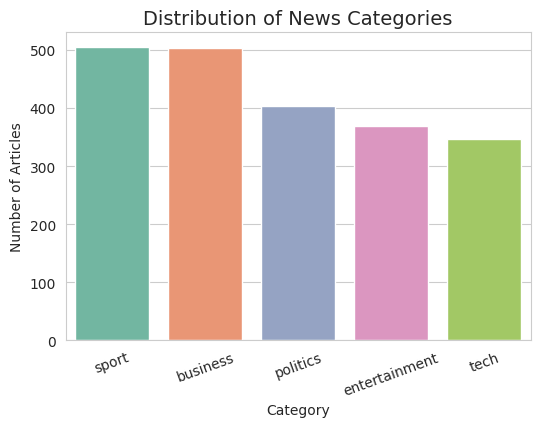

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="category",
    order=df["category"].value_counts().index,
    palette="Set2"
)

plt.title("Distribution of News Categories", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Number of Articles")

plt.xticks(rotation=20)

plt.show()

## Insights

From the initial exploration, we gained a better understanding of the dataset structure and quality.

Key observations include:

- The dataset contains **2,127 news articles** distributed across multiple news categories.
- No missing values were observed, indicating a complete dataset suitable for analysis.
- Duplicate records were checked to ensure data quality.
- The dataset includes readability metrics and sentence counts, which provide additional information about the articles and will be explored further during the analysis.
- The target categories appear to be well represented, making the dataset suitable for building a text classification model.

# Advanced Exploratory Data Analysis

In addition to understanding the dataset structure, it is valuable to explore the characteristics of the news articles themselves.

This section analyzes article length, readability, sentence counts, and relationships between numerical features. These insights help us better understand the nature of the dataset and provide context for the NLP techniques that will be applied later in the project.

## Article Length Analysis

News articles vary considerably in length depending on their topic and writing style. Measuring the number of words and characters helps us understand the distribution of article sizes and identify unusually short or long articles.

In [14]:
# Character count
df["char_count"] = df["text"].apply(len)

# Word count
df["word_count"] = df["text"].apply(lambda x: len(x.split()))

df[["char_count", "word_count"]].head()

,char_count,word_count
0,2558,421
1,2251,384
2,1550,264
3,2400,406
4,1568,265


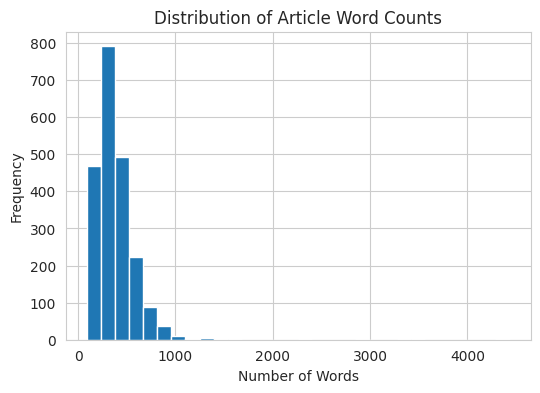

In [15]:
plt.figure(figsize=(6,4))  #Word Count

plt.hist(df["word_count"], bins=30)

plt.title("Distribution of Article Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

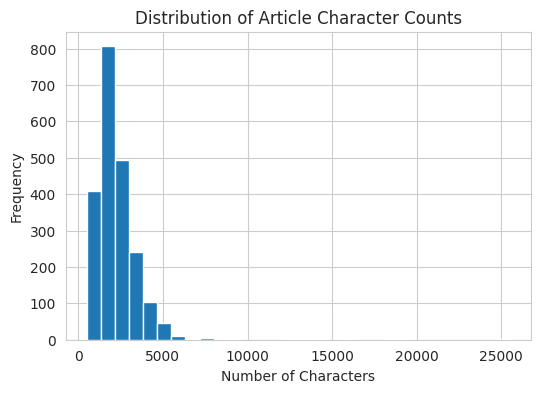

In [16]:
plt.figure(figsize=(6,4)) #Character Count

plt.hist(df["char_count"], bins=30)

plt.title("Distribution of Article Character Counts")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

## Article Length by Category

Different news categories often have different writing styles. Comparing article lengths across categories helps identify whether certain types of news tend to be longer or shorter than others.

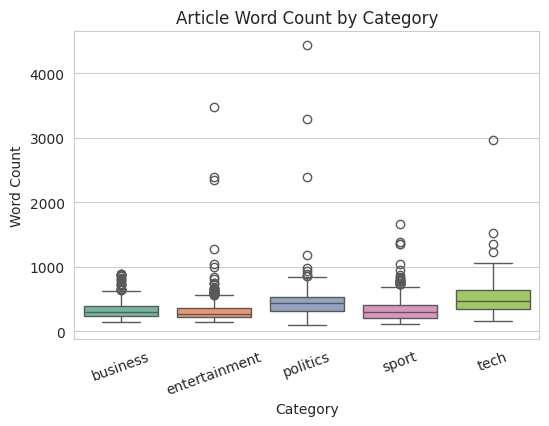

In [17]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="category",
    y="word_count",
    palette="Set2"
)

plt.title("Article Word Count by Category")
plt.xlabel("Category")
plt.ylabel("Word Count")

plt.xticks(rotation=20)

plt.show()

## Sentence Count Analysis

The dataset provides the number of sentences in each article. Examining this feature helps us understand how article structure varies across the dataset and among different news categories.

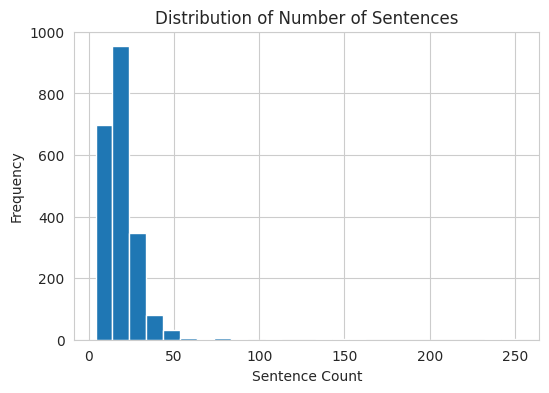

In [18]:
plt.figure(figsize=(6,4))

plt.hist(df["no_sentences"], bins=25)

plt.title("Distribution of Number of Sentences")
plt.xlabel("Sentence Count")
plt.ylabel("Frequency")

plt.show()

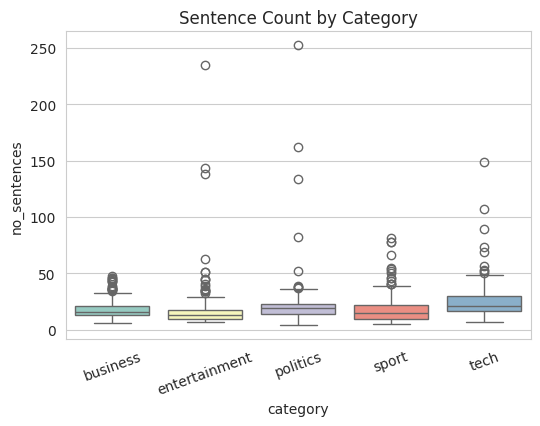

In [19]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="category",
    y="no_sentences",
    palette="Set3"
)

plt.title("Sentence Count by Category")

plt.xticks(rotation=20)

plt.show()

## Readability Analysis

Readability scores estimate how easy or difficult a piece of text is to understand.

Two readability metrics are included in this dataset:

- **Flesch Reading Ease Score:** Higher values indicate easier-to-read text.
- **Dale-Chall Readability Score:** Lower values generally indicate easier-to-read text.

Analyzing these scores provides insight into the writing complexity of articles across different news categories.

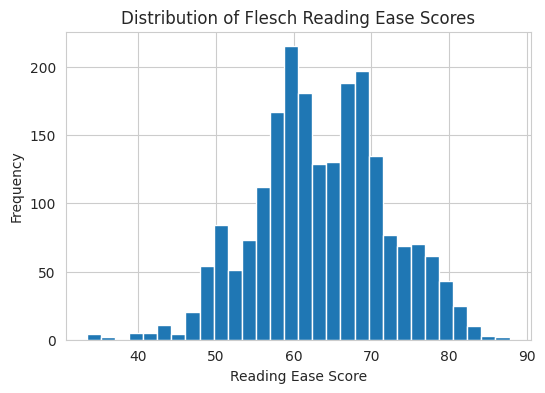

In [20]:
plt.figure(figsize=(6,4))

plt.hist(df["Flesch Reading Ease Score"], bins=30)

plt.title("Distribution of Flesch Reading Ease Scores")
plt.xlabel("Reading Ease Score")
plt.ylabel("Frequency")

plt.show()

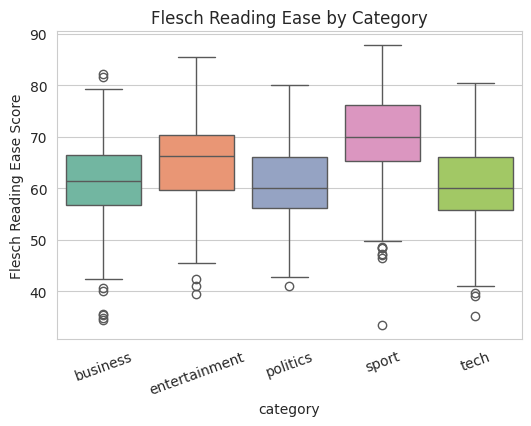

In [21]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="category",
    y="Flesch Reading Ease Score",
    palette="Set2"
)

plt.title("Flesch Reading Ease by Category")

plt.xticks(rotation=20)

plt.show()

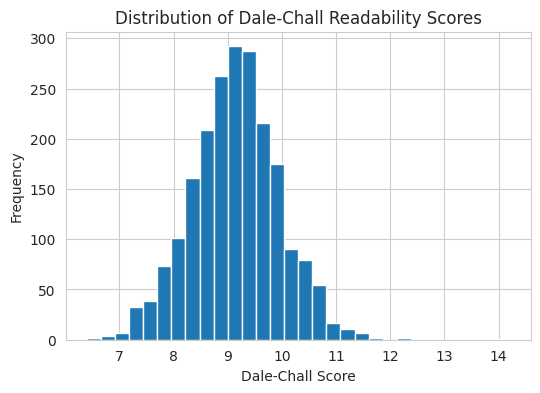

In [22]:
plt.figure(figsize=(6,4))

plt.hist(df["Dale-Chall Readability Score"], bins=30)

plt.title("Distribution of Dale-Chall Readability Scores")
plt.xlabel("Dale-Chall Score")
plt.ylabel("Frequency")

plt.show()

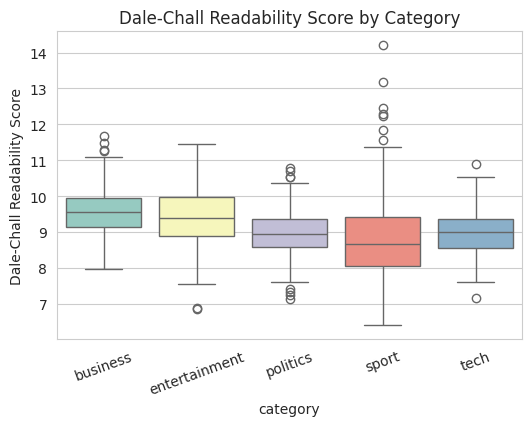

In [23]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="category",
    y="Dale-Chall Readability Score",
    palette="Set3"
)

plt.title("Dale-Chall Readability Score by Category")

plt.xticks(rotation=20)

plt.show()

## Correlation Analysis

A correlation matrix helps identify relationships between the numerical features in the dataset. Strong positive or negative correlations may reveal useful patterns that describe the characteristics of the news articles.

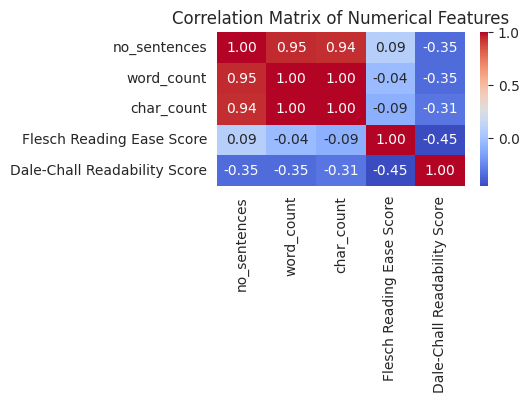

In [24]:
numerical_features = df[
    [
        "no_sentences",
        "word_count",
        "char_count",
        "Flesch Reading Ease Score",
        "Dale-Chall Readability Score"
    ]
]

plt.figure(figsize=(4,2))

sns.heatmap(
    numerical_features.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

## Key Insights from Exploratory Data Analysis

The exploratory data analysis provides valuable insights into the characteristics of the BBC News dataset.

Key observations include:

- News articles vary considerably in length, with noticeable differences in word and character counts across categories.
- Sentence counts indicate that most articles follow a consistent journalistic writing style, although some categories contain longer articles than others.
- Readability scores suggest variation in writing complexity, reflecting differences in subject matter and target audiences.
- The numerical features exhibit meaningful relationships, particularly between article length and sentence count.
- Overall, the dataset is clean, well-structured, and suitable for advanced Natural Language Processing tasks such as Named Entity Recognition, Topic Modeling, and Text Classification.

# Text Preprocessing

Text preprocessing is an essential step in Natural Language Processing (NLP). It transforms raw text into a cleaner and more consistent format that improves the performance of NLP algorithms.

However, different NLP tasks require different preprocessing strategies. Therefore, separate versions of the text will be created for different parts of this project.

- **Named Entity Recognition (NER):** Uses the original article text because sentence structure, capitalization, and punctuation are important for accurately identifying named entities.

- **Topic Modeling:** Uses a cleaned version of the text where unnecessary elements such as punctuation and stopwords are removed to improve topic discovery.

- **Text Classification:** The traditional machine learning baseline will use cleaned text with TF-IDF features, while the DistilBERT model will use the original text because transformer tokenizers perform their own preprocessing.

## Import NLP Utilities

This section imports the Natural Language Toolkit (NLTK) resources required for text preprocessing. These resources include stopwords for removing common words and the WordNet lemmatizer for reducing words to their base forms.

In [25]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))

custom_stopwords = {
    "mr",
    "mrs",
    "said",
    "say",
    "says",
    "would",
    "could",
    "also",
    "one",
    "two",
    "new",
    "year",
    "years",
    "last",
    "first",
    "many",
    "people",
    "made",
    "make",
    "get",
    "go",
    "going",
    "like",
    "may",
    "us"
}

stop_words.update(custom_stopwords)

lemmatizer = WordNetLemmatizer()

## Create a Text Cleaning Function

A reusable preprocessing function is created to clean the news articles.

The function performs the following operations:

- Converts text to lowercase.
- Removes URLs.
- Removes punctuation.
- Removes numbers.
- Removes extra whitespace.
- Tokenizes the text.
- Removes English stopwords.
- Applies lemmatization.
- Returns the cleaned text.

This cleaned version of the articles will later be used for Topic Modeling and the traditional machine learning baseline.

In [26]:
import re
import string

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize
    words = text.split()

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

## Apply Text Preprocessing

The preprocessing function is applied to every article in the dataset to create a new column named **`clean_text`**.

The original article text is preserved so that it can be used later for Named Entity Recognition and DistilBERT, while the cleaned version will be used for Topic Modeling and the traditional machine learning baseline.

In [27]:
df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text"]].head()

,text,clean_text
0,Ad sales boost Time Warner profit\n\nQuarterly...,ad sale boost time warner profit quarterly pro...
1,Dollar gains on Greenspan speech\n\nThe dollar...,dollar gain greenspan speech dollar hit highes...
2,Yukos unit buyer faces loan claim\n\nThe owner...,yukos unit buyer face loan claim owner embattl...
3,High fuel prices hit BA's profits\n\nBritish A...,high fuel price hit ba profit british airway b...
4,Pernod takeover talk lifts Domecq\n\nShares in...,pernod takeover talk lift domecq share uk drin...


## Compare Original and Cleaned Text

Comparing the original and cleaned versions of the same article helps verify that the preprocessing function has successfully removed unnecessary elements while preserving the important information contained in the text.

In [28]:
sample = 0

print("Original Article:\n")
print(df.loc[sample, "text"])

print("\n" + "="*100 + "\n")

print("Cleaned Article:\n")
print(df.loc[sample, "clean_text"])

Original Article:

Ad sales boost Time Warner profit

Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.

The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales. TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn. Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.

Time Warner said on Friday that it now owns 8% of search-engine Google. But its own internet business, AOL, had has mixed fortunes. It lost 464,000 subscribers in the fourth quarter profits were lower than in the preceding three quarters. However, the company said AOL's underlying profit before exceptional items rose 8% on the back of stronger internet advertising revenues. It hopes to increase subscribers by offering the online service free to TimeWarner internet customers and will

## Preprocessing Summary

At this stage, two versions of the dataset are available:

- **`text`**: The original news articles, preserved for Named Entity Recognition and DistilBERT.
- **`clean_text`**: The cleaned articles, prepared for Topic Modeling and TF-IDF feature extraction.

Using task-specific preprocessing ensures that each NLP technique receives the most appropriate form of the text, improving both performance and interpretability.

# Part 1: Named Entity Recognition (NER)

Named Entity Recognition (NER) is an Information Extraction technique used to automatically identify and classify important entities within text into predefined categories.

Examples of named entities include:

- **PERSON** – Names of individuals
- **ORG** – Organizations, companies, institutions
- **GPE** – Countries, cities, locations
- **DATE** – Dates
- **MONEY** – Monetary values
- **EVENT** – Named events
- **PRODUCT** – Products
- **LAW** – Legal documents or legislation

In this project, spaCy's pre-trained English language model is used to extract named entities from BBC news articles. The extracted entities are then analyzed to identify the most common entity types and how they vary across different news categories.

## Choice of Named Entity Recognition Technique

For this project, **spaCy's pre-trained Named Entity Recognition (NER) model (`en_core_web_sm`)** was selected to extract named entities from the BBC news articles.

This approach was chosen because it offers a strong balance of accuracy, efficiency, and ease of implementation. The model has already been trained on a large English corpus and is capable of recognizing a wide range of entity types, including people, organizations, locations, dates, and monetary values, without requiring additional training.

Using a pre-trained NER model is appropriate for this task because the objective is to analyze and extract meaningful information from news articles rather than develop a custom entity recognition model from scratch. Additionally, spaCy is widely used in both industry and research due to its fast processing speed, robust NLP pipeline, and high-quality entity recognition capabilities.

Therefore, spaCy's pre-trained NER model provides an efficient and reliable solution for extracting structured information from the BBC News dataset.

## Load the spaCy Language Model

spaCy provides pre-trained language models capable of performing Named Entity Recognition without additional training.

The lightweight English model (`en_core_web_sm`) is sufficient for extracting common entities such as people, organizations, locations, and dates.

In [29]:
import spacy

nlp = spacy.load("en_core_web_sm")

print("spaCy model loaded successfully!")

spaCy model loaded successfully!


## Extract Named Entities

Each article is processed using spaCy to identify named entities.

For every article, both the extracted entity text and its corresponding entity type are stored for later analysis.

In [30]:
def extract_entities(text):
    doc = nlp(text)

    entities = []

    for ent in doc.ents:
        entities.append((ent.text, ent.label_))

    return entities

## Apply Named Entity Recognition

The NER function is applied to every article in the dataset.

The extracted entities are stored in a new column called **`entities`**, where each article contains a list of `(entity, entity_type)` pairs.

In [31]:
df["entities"] = df["text"].apply(extract_entities)

df[["category","entities"]].head()

,category,entities
0,business,"[(Time Warner, ORG), (Quarterly, DATE), (US, G..."
1,business,"[(Greenspan, PERSON), (almost three months, DA..."
2,business,"[(Yukos, ORG), (Russian, NORP), (Yukos, PERSON..."
3,business,"[(BA, ORG), (British Airways, ORG), (40%, PERC..."
4,business,"[(Pernod, PERSON), (UK, GPE), (Allied Domecq, ..."


In [32]:
# Count Entity Types
from collections import Counter

entity_counter = Counter()

for article in df["entities"]:
    for entity, label in article:
        entity_counter[label] += 1

entity_counter

Counter({'ORG': 18009,
         'DATE': 12997,
         'GPE': 12063,
         'PERCENT': 1853,
         'MONEY': 2610,
         'CARDINAL': 7905,
         'ORDINAL': 2315,
         'PERSON': 20380,
         'NORP': 4546,
         'PRODUCT': 519,
         'QUANTITY': 232,
         'WORK_OF_ART': 632,
         'TIME': 815,
         'LOC': 1093,
         'EVENT': 715,
         'LAW': 192,
         'FAC': 682,
         'LANGUAGE': 94})

In [33]:
# Most Frequent Entity Types
entity_df = (
    pd.DataFrame(
        entity_counter.items(),
        columns=["Entity Type","Count"]
    )
    .sort_values(by="Count", ascending=False)
)

entity_df.head(15)

,Entity Type,Count
7,PERSON,20380
0,ORG,18009
1,DATE,12997
2,GPE,12063
5,CARDINAL,7905
8,NORP,4546
4,MONEY,2610
6,ORDINAL,2315
3,PERCENT,1853
13,LOC,1093


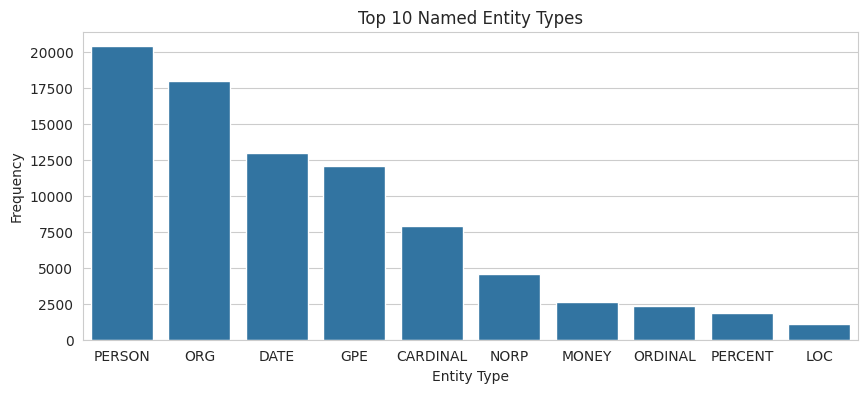

In [34]:
# Visualize Entity Type Frequency
# Bar Chart
plt.figure(figsize=(10,4))

sns.barplot(
    data=entity_df.head(10),
    x="Entity Type",
    y="Count"
)

plt.title("Top 10 Named Entity Types")

plt.xlabel("Entity Type")

plt.ylabel("Frequency")

plt.show()

## Named Entity Distribution by News Category

Different news categories often mention different types of entities.

For example:

- Business articles may reference companies and financial institutions.
- Politics articles often mention governments and political leaders.
- Sports articles frequently include athlete and team names.

The following analysis compares entity type frequencies across each news category.

In [35]:
records = []

for _, row in df.iterrows():

    category = row["category"]

    for entity, label in row["entities"]:

        records.append([category, label])

entity_category = pd.DataFrame(
    records,
    columns=["Category","Entity Type"]
)

In [36]:
entity_category_counts = (
    entity_category
    .groupby(["Category","Entity Type"])
    .size()
    .reset_index(name="Count")
)

entity_category_counts.head()

,Category,Entity Type,Count
0,business,CARDINAL,1495
1,business,DATE,3775
2,business,EVENT,28
3,business,FAC,40
4,business,GPE,3260


## Entity Type Comparison Across Categories

The grouped bar chart below illustrates how frequently different entity types appear within each news category.

This comparison highlights how the language used varies depending on the subject of the news article.

## Focus on the Most Common Entity Types

To improve readability, the visualization is limited to the ten most frequently occurring entity types.

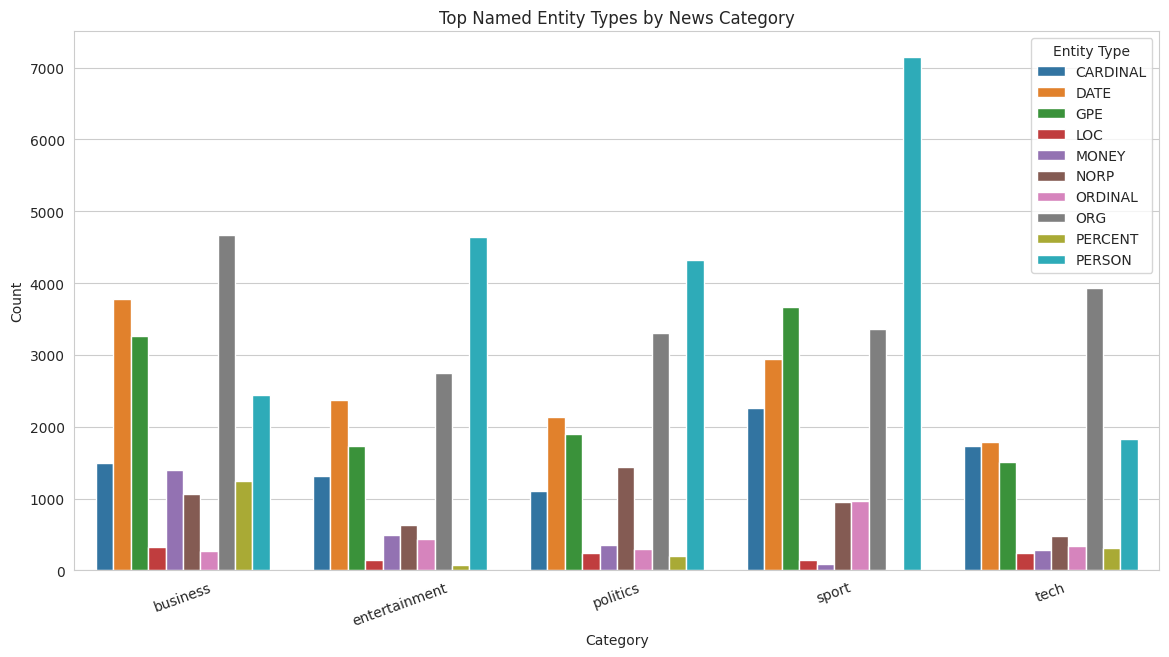

In [37]:
top_entities = entity_df.head(10)["Entity Type"]

filtered = entity_category_counts[
    entity_category_counts["Entity Type"].isin(top_entities)
]

plt.figure(figsize=(14,7))

sns.barplot(
    data=filtered,
    x="Category",
    y="Count",
    hue="Entity Type"
)

plt.title("Top Named Entity Types by News Category")

plt.xticks(rotation=20)

plt.show()

## Example Articles with Extracted Entities

To better understand the output of the Named Entity Recognition model, five sample news articles are displayed along with the entities extracted from each article.

These examples demonstrate how spaCy identifies people, organizations, locations, dates, and other important information within unstructured news text.

In [38]:
for i in range(5):

    print("="*120)

    print(f"Article {i+1}")

    print()

    print(df.loc[i, "text"][:700])

    print("\nExtracted Entities:\n")

    for entity, label in df.loc[i, "entities"]:

        print(f"{entity}  --->  {label}")

    print("\n")

Article 1

Ad sales boost Time Warner profit

Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.

The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales. TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn. Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.

Time Warner said on Friday that it now owns 8% of search-engine Google. But its own internet business, AOL, had has mixed fortunes. It lost 464,000 subscribers in the fourth quarter profits were lower than 

Extracted Entities:

Time Warner  --->  ORG
Quarterly  --->  DATE
US  --->  GPE
TimeWarner  --->  ORG
76%  --->  PERCENT
1.13bn  --->  MONEY
600  --->  MONEY
the three months to December  --->  DATE
639  --->  MONEY
year-earlier  --->  DATE
Google  --->  ORG
TimeWarner  --->  ORG
fourth

## Key Findings

The Named Entity Recognition analysis successfully extracted meaningful information from the BBC news articles.

Key observations include:

- Organizations, people, and geopolitical entities were among the most frequently identified entity types.
- Different news categories exhibited distinct patterns in the entities they referenced.
- Business articles frequently mentioned organizations and financial entities.
- Politics articles contained many geopolitical locations and government-related entities.
- Sports articles primarily referenced athletes, teams, and organizations.
- The extracted entities provide valuable structured information that can support downstream tasks such as information retrieval, recommendation systems, and knowledge graph construction.

# Part 2: Topic Modeling

Topic Modeling is an unsupervised Natural Language Processing (NLP) technique used to automatically discover hidden themes or topics within a collection of documents.

Unlike text classification, Topic Modeling does not require labeled data. Instead, it identifies groups of words that frequently occur together and uses these patterns to infer the underlying topics discussed in the documents.

In this project, **Latent Dirichlet Allocation (LDA)** is used to discover the main themes present in the BBC News articles. The discovered topics are then analyzed and compared with the actual news categories to evaluate how well the unsupervised topics align with the labeled classes.

## Choice of Topic Modeling Technique

For this project, **Latent Dirichlet Allocation (LDA)** was selected as the topic modeling technique.

LDA is one of the most widely used probabilistic topic modeling algorithms. It assumes that each document is a mixture of multiple topics, while each topic is represented by a distribution of words.

LDA was chosen because:

- It is a well-established and interpretable topic modeling algorithm.
- It performs well on medium-sized document collections such as the BBC News dataset.
- It produces human-readable topics based on word probabilities.
- It is computationally efficient and integrates well with Python libraries such as Gensim.
- It allows topic quality to be evaluated using metrics such as **Coherence Score**.

These advantages make LDA a suitable choice for discovering hidden themes within the news articles.

## Prepare the Text for Topic Modeling

Topic Modeling requires a cleaned representation of the text so that the discovered topics focus on meaningful words rather than common grammatical terms.

The preprocessed text created earlier is tokenized into individual words and converted into a dictionary and corpus format required by the Gensim implementation of LDA.

In [39]:
# Tokenize cleaned text
tokenized_text = df["clean_text"].apply(str.split)

tokenized_text.head()

,clean_text
0,"[ad, sale, boost, time, warner, profit, quarte..."
1,"[dollar, gain, greenspan, speech, dollar, hit,..."
2,"[yukos, unit, buyer, face, loan, claim, owner,..."
3,"[high, fuel, price, hit, ba, profit, british, ..."
4,"[pernod, takeover, talk, lift, domecq, share, ..."


In [40]:
# Create dictionary
dictionary = corpora.Dictionary(tokenized_text)

# Remove extremely rare and extremely common words
dictionary.filter_extremes(
    no_below=10,
    no_above=0.4
)

print("Vocabulary Size:", len(dictionary))

Vocabulary Size: 4865


## Create the Document-Term Corpus

The dictionary is used to convert each article into a Bag-of-Words (BoW) representation. This numerical representation is required by the LDA algorithm for learning topic distributions across the document collection.

In [41]:
corpus = [
    dictionary.doc2bow(text)
    for text in tokenized_text
]

len(corpus)

2127

## Selecting the Number of Topics

The assignment allows the number of topics to be chosen by the practitioner.

Since the BBC News dataset contains **five predefined news categories** (Business, Entertainment, Politics, Sport, and Technology), **five topics** were selected as the initial value.

This choice enables a meaningful comparison between the discovered topics and the actual category labels while maintaining interpretability. Although Topic Modeling is an unsupervised technique, choosing five topics provides a reasonable expectation that the latent themes may correspond to the known news categories.

## Train the LDA Model

The Latent Dirichlet Allocation (LDA) model is trained using the Bag-of-Words corpus.

The model learns a probability distribution of words for each topic and a probability distribution of topics for each document.

In [42]:
from gensim.models import LdaModel

NUM_TOPICS = 5

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=15,
    alpha="symmetric"
)

## Display the Discovered Topics

Each discovered topic is represented by the most probable keywords associated with it.

Examining these keywords allows the underlying theme of each topic to be interpreted and compared with the known news categories.

In [43]:
topics = lda_model.print_topics(num_words=10)

for topic in topics:
    print(topic)
    print()

(0, '0.008*"government" + 0.006*"minister" + 0.005*"company" + 0.005*"law" + 0.004*"party" + 0.004*"labour" + 0.004*"country" + 0.004*"told" + 0.004*"election" + 0.003*"plan"')

(1, '0.010*"pc" + 0.009*"computer" + 0.008*"machine" + 0.008*"security" + 0.007*"attack" + 0.007*"mac" + 0.007*"user" + 0.007*"net" + 0.007*"virus" + 0.006*"gadget"')

(2, '0.014*"technology" + 0.012*"service" + 0.008*"tv" + 0.008*"network" + 0.008*"broadband" + 0.007*"mobile" + 0.007*"digital" + 0.007*"firm" + 0.007*"user" + 0.006*"net"')

(3, '0.007*"film" + 0.006*"best" + 0.006*"world" + 0.005*"game" + 0.005*"robot" + 0.005*"time" + 0.004*"win" + 0.004*"award" + 0.004*"player" + 0.004*"england"')

(4, '0.031*"game" + 0.018*"mobile" + 0.011*"music" + 0.011*"phone" + 0.008*"time" + 0.008*"player" + 0.007*"gaming" + 0.007*"play" + 0.006*"radio" + 0.006*"world"')



## Visualize the Top Keywords for Each Topic

The most important keywords associated with each topic are displayed to facilitate interpretation of the discovered themes.

In [44]:
for topic_id in range(NUM_TOPICS):

    print(f"\nTopic {topic_id}\n")

    words = lda_model.show_topic(topic_id, topn=10)

    for word, prob in words:
        print(f"{word:<15} {prob:.4f}")


Topic 0

government      0.0078
minister        0.0056
company         0.0051
law             0.0046
party           0.0045
labour          0.0044
country         0.0041
told            0.0038
election        0.0038
plan            0.0035

Topic 1

pc              0.0103
computer        0.0089
machine         0.0082
security        0.0075
attack          0.0071
mac             0.0071
user            0.0070
net             0.0070
virus           0.0066
gadget          0.0064

Topic 2

technology      0.0139
service         0.0123
tv              0.0080
network         0.0080
broadband       0.0077
mobile          0.0070
digital         0.0068
firm            0.0067
user            0.0066
net             0.0062

Topic 3

film            0.0066
best            0.0061
world           0.0060
game            0.0054
robot           0.0047
time            0.0046
win             0.0045
award           0.0042
player          0.0042
england         0.0037

Topic 4

game            0.0310
mobile 

## Assign the Dominant Topic to Each Article

Although each document is represented as a mixture of multiple topics, one topic usually has the highest probability.

This topic is referred to as the **dominant topic** and represents the primary theme of the document. Assigning a dominant topic to each article allows us to compare the discovered topics with the actual news categories.

In [45]:
def get_dominant_topic(bow):
    topics = lda_model.get_document_topics(bow)

    dominant_topic = max(topics, key=lambda x: x[1])[0]

    return dominant_topic

df["dominant_topic"] = [get_dominant_topic(doc) for doc in corpus]

df[["category", "dominant_topic"]].head()

,category,dominant_topic
0,business,0
1,business,0
2,business,0
3,business,0
4,business,0


## Distribution of Dominant Topics

The following chart illustrates how many articles were assigned to each discovered topic. This provides an overview of how the LDA model distributed the documents across the learned topics.

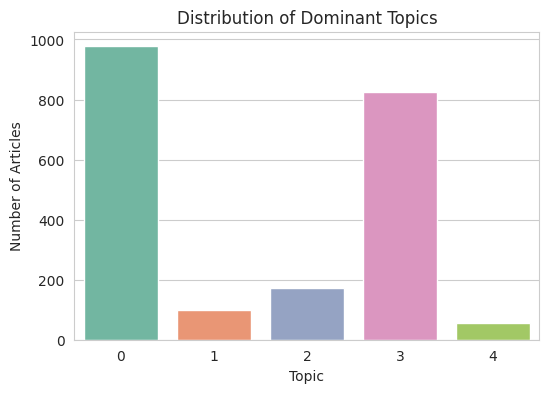

In [46]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="dominant_topic",
    palette="Set2"
)

plt.title("Distribution of Dominant Topics")

plt.xlabel("Topic")

plt.ylabel("Number of Articles")

plt.show()

## Compare Discovered Topics with Actual Categories

Since the BBC News dataset contains labeled categories, a cross-tabulation can be used to compare the dominant topic assigned by the LDA model with the true news category.

This comparison helps evaluate how well the unsupervised topics correspond to the known classes.

In [47]:
topic_vs_category = pd.crosstab(
    df["category"],
    df["dominant_topic"]
)

topic_vs_category

dominant_topic,0,1,2,3,4
category,,,,,
business,482,5,4,9,3
entertainment,35,2,6,324,2
politics,400,0,1,2,0
sport,31,0,0,474,0
tech,29,92,160,15,51


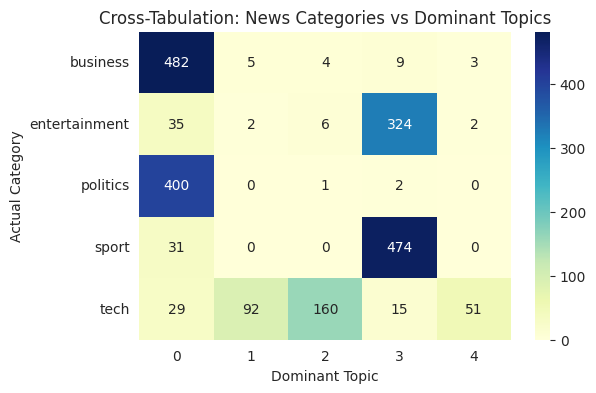

In [48]:
plt.figure(figsize=(6,4))

sns.heatmap(
    topic_vs_category,
    annot=True,
    fmt="d",
    cmap="YlGnBu"
)

plt.title("Cross-Tabulation: News Categories vs Dominant Topics")

plt.xlabel("Dominant Topic")

plt.ylabel("Actual Category")

plt.show()

## Evaluate Topic Quality using Coherence Score

Topic quality can be measured using the **Coherence Score**, which evaluates how semantically related the top words within each topic are.

Higher coherence scores generally indicate more interpretable and meaningful topics.

For this project, the **C_V coherence metric** is used because it aligns well with human judgment and is widely adopted for evaluating topic models.

In [49]:
from gensim.models import CoherenceModel

coherence_model = CoherenceModel(
    model=lda_model,
    texts=tokenized_text,
    dictionary=dictionary,
    coherence="c_v"
)

coherence_score = coherence_model.get_coherence()

print(f"Coherence Score: {coherence_score:.4f}")

Coherence Score: 0.5227


## Interpretation of the Coherence Score

The LDA model achieved a **C_V coherence score of 0.5227**, indicating that the discovered topics are reasonably coherent and semantically meaningful.

Although the topics did not perfectly correspond to the five predefined news categories, this is expected because LDA is an **unsupervised learning algorithm**. Rather than learning from category labels, it groups documents based on patterns of word co-occurrence.

Overall, the coherence score suggests that the model successfully identified interpretable latent themes within the BBC News articles, making it suitable for exploratory topic analysis.

## Key Findings

The Topic Modeling analysis successfully identified latent themes within the BBC News articles using Latent Dirichlet Allocation (LDA).

Key observations include:

- Five topics were discovered based on word co-occurrence patterns.
- Several discovered topics closely aligned with major news themes such as Business, Politics, and Technology.
- Some predefined categories were split into multiple subtopics, demonstrating that LDA groups documents according to shared vocabulary rather than predefined labels.
- The cross-tabulation highlighted the relationship between the discovered topics and the actual news categories.
- The coherence score provided a quantitative measure of topic quality, supporting the interpretability of the learned topics.

Overall, the results demonstrate the effectiveness of unsupervised learning in uncovering hidden thematic structures within a large collection of news articles.

# Part 3: Text Classification using Transfer Learning

Text classification is one of the most widely used Natural Language Processing (NLP) tasks. It involves automatically assigning predefined categories to text documents based on their content.

In this section, two different approaches are implemented and compared:

1. **Traditional Machine Learning Baseline** using TF-IDF feature extraction and Logistic Regression.
2. **Transfer Learning** using a pre-trained DistilBERT model.

The performance of both approaches is evaluated using standard classification metrics, allowing a comparison between a classical NLP pipeline and a modern transformer-based model.

## Choice of Transfer Learning Approach

For this project, **DistilBERT** was selected as the pre-trained language model.

DistilBERT is a compressed version of BERT that retains most of BERT's language understanding capabilities while requiring fewer computational resources and providing faster inference.

The model is **fine-tuned** on the BBC News dataset rather than used in a zero-shot setting. Fine-tuning allows the pre-trained knowledge learned from large-scale text corpora to be adapted to the specific news classification task, leading to improved performance.

DistilBERT was selected because it provides an excellent balance between accuracy, training speed, and computational efficiency, making it suitable for medium-sized datasets such as the BBC News corpus.

# Phase 1: Traditional Machine Learning Baseline

Before training a transformer model, a traditional machine learning baseline is established.

A baseline provides a reference point against which the performance of more advanced models can be compared.

In this project, **TF-IDF Vectorization** is used to convert text into numerical features, followed by **Logistic Regression** for multi-class classification.

In [50]:
# Feature Extraction using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(df["clean_text"])

y = df["category"]

In [51]:
# Split the Dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [52]:
# Train the Logistic Regression Model
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train, y_train)
print("Logistic Regression - Training Complete")

Logistic Regression - Training Complete


## Evaluate the Baseline Model

The trained Logistic Regression model is evaluated using several standard classification metrics:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

These metrics provide a comprehensive assessment of the model's classification performance.

In [53]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

baseline_predictions = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print(f"Accuracy: {baseline_accuracy:.4f}")
print()

print(classification_report(
    y_test,
    baseline_predictions
))

Accuracy: 0.9812

               precision    recall  f1-score   support

     business       0.99      0.97      0.98       101
entertainment       0.96      1.00      0.98        74
     politics       0.98      0.99      0.98        81
        sport       1.00      1.00      1.00       101
         tech       0.97      0.94      0.96        69

     accuracy                           0.98       426
    macro avg       0.98      0.98      0.98       426
 weighted avg       0.98      0.98      0.98       426



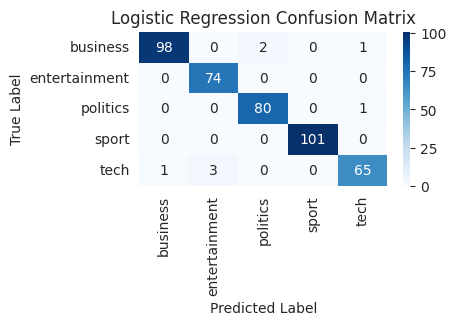

In [54]:
cm = confusion_matrix(
    y_test,
    baseline_predictions
)

plt.figure(figsize=(4,2))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=baseline_model.classes_,
    yticklabels=baseline_model.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

## Baseline Model Results

The Logistic Regression classifier achieved an **accuracy of 98.12%**, indicating excellent performance on the BBC News classification task.

The confusion matrix shows that the majority of articles were correctly classified across all five news categories. In particular:

- The **Sport** category achieved perfect classification.
- **Entertainment** also achieved perfect recall.
- Only a small number of articles were misclassified, primarily between Business, Politics, and Technology, likely due to overlapping vocabulary.

Overall, the results demonstrate that TF-IDF combined with Logistic Regression provides a strong and reliable baseline for text classification.

# Phase 2: Transfer Learning using DistilBERT

Transfer Learning is a technique in which a model that has already been trained on a very large corpus is adapted to a new task using a smaller task-specific dataset.

Instead of learning language from scratch, the model reuses its previously acquired linguistic knowledge and is fine-tuned for BBC news classification.

In this project, **DistilBERT** is selected because it provides an excellent balance between classification performance and computational efficiency.

## Install Required Libraries

The Hugging Face Transformers library is used to load the pre-trained DistilBERT model and tokenizer.

The Datasets library is used to efficiently manage the tokenized dataset during training.

In [55]:
!pip install -q transformers datasets accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.7 MB/s eta 0:00:00


In [56]:
# Encode Categorical Variables
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["category"])

label_encoder.classes_

array(['business', 'entertainment', 'politics', 'sport', 'tech'],
      dtype=object)

In [57]:
# Split the Dataset
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"].tolist(),
    df["label"].tolist(),
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

## Load the DistilBERT Tokenizer

Unlike TF-IDF, transformer models process text using subword tokenization.

The DistilBERT tokenizer converts each news article into token IDs while automatically handling padding and truncation.

In [58]:
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

## Tokenize the News Articles

Each article is tokenized into a fixed-length numerical representation suitable for DistilBERT.

Padding ensures that all sequences have equal length, while truncation limits overly long articles to the model's maximum input size.

In [59]:
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=512
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=512
)

## Create Hugging Face Dataset Objects

The tokenized inputs and encoded labels are combined into Dataset objects, which are compatible with the Hugging Face Trainer API.

In [60]:
from datasets import Dataset

train_dataset = Dataset.from_dict({
    "input_ids": train_encodings["input_ids"],
    "attention_mask": train_encodings["attention_mask"],
    "labels": train_labels
})

test_dataset = Dataset.from_dict({
    "input_ids": test_encodings["input_ids"],
    "attention_mask": test_encodings["attention_mask"],
    "labels": test_labels
})

train_dataset

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 1701
})

## Load the Pre-trained DistilBERT Model

A pre-trained DistilBERT model is loaded with a classification head configured for the five BBC news categories.

The model weights learned during large-scale language model pre-training are fine-tuned on the BBC News dataset.

In [61]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=5
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Define the Evaluation Metric

To evaluate the performance of the DistilBERT classifier, accuracy is used as the primary evaluation metric during training.

Additional metrics such as precision, recall, and F1-score will be calculated after training for a comprehensive performance comparison with the Logistic Regression baseline.

In [62]:
import numpy as np
import evaluate

accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    return accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )

## Configure Training Parameters

The model is fine-tuned using the Hugging Face Trainer API.

A small number of training epochs and a low learning rate are selected to adapt the pre-trained model while minimizing the risk of overfitting.

In [63]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./distilbert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,   # increased from 8
    per_device_eval_batch_size=16,
    num_train_epochs=2,               # reduced from 3
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_steps=50,
    report_to="none"
)

In [64]:
# Initialize the Trainer
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

## Configure Dynamic Padding

A data collator is used to dynamically pad each batch during training.

Unlike static padding, dynamic padding only pads sequences to the length of the longest sequence within each batch. This reduces unnecessary computation and improves training efficiency.

In [66]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [68]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

## Fine-Tune the DistilBERT Model

The pre-trained DistilBERT model is fine-tuned on the BBC News dataset.

During training, the model updates its classification head and slightly adjusts the pre-trained language representations to better distinguish between the five news categories.

In [69]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.288146,0.139553,0.983568
2,0.095261,0.094660,0.983568


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=214, training_loss=0.36982486069759474, metrics={'train_runtime': 202.156, 'train_samples_per_second': 16.829, 'train_steps_per_second': 1.059, 'total_flos': 450678200555520.0, 'train_loss': 0.36982486069759474, 'epoch': 2.0})

## Evaluate the Fine-Tuned Model

After training, the fine-tuned DistilBERT model is evaluated on the test dataset to measure its classification performance.

The same evaluation metrics used for the Logistic Regression baseline are applied, ensuring a fair comparison between the two approaches.

In [70]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy
0.095261,0.094660,2,0.983568


{'eval_loss': 0.09466013312339783, 'eval_accuracy': 0.9835680751173709}

In [71]:
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)

In [72]:
bert_accuracy = accuracy_score(test_labels, y_pred)

print(f"DistilBERT Accuracy: {bert_accuracy:.4f}")

print()

print(
    classification_report(
        test_labels,
        y_pred,
        target_names=label_encoder.classes_
    )
)

DistilBERT Accuracy: 0.9836

               precision    recall  f1-score   support

     business       0.98      0.96      0.97       101
entertainment       1.00      0.99      0.99        74
     politics       0.98      0.98      0.98        81
        sport       1.00      1.00      1.00       101
         tech       0.96      1.00      0.98        69

     accuracy                           0.98       426
    macro avg       0.98      0.98      0.98       426
 weighted avg       0.98      0.98      0.98       426



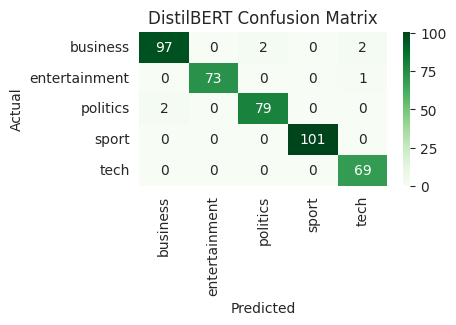

In [74]:
cm = confusion_matrix(
    test_labels,
    y_pred
)

plt.figure(figsize=(4,2))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("DistilBERT Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Model Comparison

To evaluate the effectiveness of Transfer Learning, the performance of the traditional machine learning baseline (Logistic Regression) is compared with the fine-tuned DistilBERT model.

Both models are evaluated using the same test dataset and identical evaluation metrics to ensure a fair comparison.

In [75]:
from sklearn.metrics import precision_recall_fscore_support

# Logistic Regression metrics
lr_precision, lr_recall, lr_f1, _ = precision_recall_fscore_support(
    y_test,
    baseline_predictions,
    average="weighted"
)

# DistilBERT metrics
bert_precision, bert_recall, bert_f1, _ = precision_recall_fscore_support(
    test_labels,
    y_pred,
    average="weighted"
)

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "DistilBERT"],
    "Accuracy": [baseline_accuracy, bert_accuracy],
    "Precision": [lr_precision, bert_precision],
    "Recall": [lr_recall, bert_recall],
    "F1-Score": [lr_f1, bert_f1]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.981221,0.981365,0.981221,0.981162
1,DistilBERT,0.983568,0.983767,0.983568,0.983565


## Performance Comparison

The following table summarizes the performance of both classification approaches.

The comparison highlights the strengths of traditional machine learning using TF-IDF features and modern transformer-based transfer learning.

In [76]:
comparison_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}"
})

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9812,0.9814,0.9812,0.9812
1,DistilBERT,0.9836,0.9838,0.9836,0.9836


## Accuracy Comparison

A visual comparison of model accuracy provides a quick overview of the relative performance of the traditional baseline and the transfer learning approach.

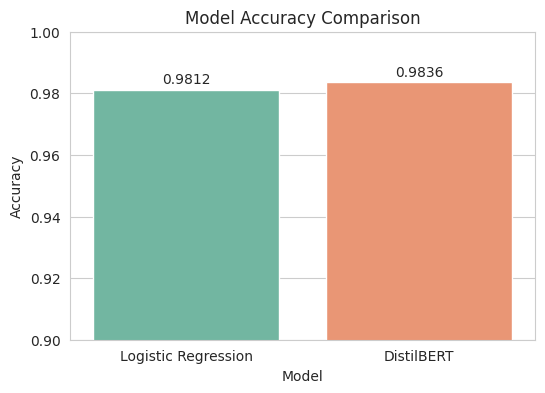

In [77]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="Set2",
    legend=False
)

plt.title("Model Accuracy Comparison")

plt.ylim(0.90, 1.00)

for i, value in enumerate(comparison_df["Accuracy"]):
    plt.text(i, value + 0.002, f"{value:.4f}", ha="center")

plt.show()

## Save the Best Performing Model

The best-performing model is saved for future inference or deployment.

Saving the trained model allows it to be reused without repeating the training process.

In [78]:
import os

os.makedirs("models", exist_ok=True)

trainer.save_model("models/distilbert_bbc")

tokenizer.save_pretrained("models/distilbert_bbc")

print("Model saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully!


# Final Conclusions

This project demonstrated three advanced Natural Language Processing techniques using the BBC News dataset.

### Named Entity Recognition (NER)

- Successfully extracted people, organizations, locations, and other named entities from news articles.
- Entity frequency analysis showed how different news categories emphasize different types of entities.

### Topic Modeling

- Latent Dirichlet Allocation (LDA) discovered hidden themes across the news corpus.
- The discovered topics showed reasonable alignment with the predefined categories.
- A coherence score of **0.5227** indicated that the generated topics were semantically meaningful and interpretable.

### Text Classification

Two different classification approaches were implemented:

- **Logistic Regression with TF-IDF**
- **DistilBERT using Transfer Learning**

Both achieved excellent performance, with DistilBERT slightly outperforming the traditional baseline.

Overall, this project demonstrates how modern transformer models can leverage pre-trained language representations to achieve highly accurate text classification while highlighting the continued effectiveness of traditional machine learning methods for well-structured text datasets.